# AstraCell — The External Positive Control

**v0.3 proved AstraCell refuses. It could not prove AstraCell refuses for a *reason*.**

A negative control — a healthy cell, correctly not diagnosed — is passed by a diagnostic that never
diagnoses anything. v0.3 shipped one of those and did not know it. Its external bias gate projected
the very trace it was about to fit and called the projection "structural bias"; since a linear fit to
a residual *is* that projection, the gate's statistic was pinned at 1σ and `REFUSE_MODEL_BIAS` came
back for **any data whatsoever**.

This notebook is how that was found, and what replaced it. We inject a real fault into the PyBaMM
cell and ask the complementary question:

> When the external cell really is broken, does AstraCell find it — and can it still tell a real
> fault from its own model error?

> ⚠️ **Still synthetic.** PyBaMM is a sophisticated *model*, and the fault is one we injected. The
> healthy baseline used to correct the phantom is the *identical simulation*, which no workshop can
> supply — so every number here is an **upper bound** on what a real baseline could deliver. Read
> [`docs/POSITIVE_CONTROL.md`](../docs/POSITIVE_CONTROL.md) §5 before quoting any of it. PyBaMM is
> optional (`pip install -e '.[pybamm]'`); §1 runs without it, the rest skip cleanly.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from astracell.calibration import (
    CAPACITY_TARGET,
    R0_TARGET,
    build_evidence,
    build_external_observer,
    detection_metrics,
    external_scenario,
    observer_voltage,
    prepare_external,
    pulse_profile,
    run_trials,
    verdict_distribution,
)
from astracell.cell.ocv import NMC_LIKE, ocv_from_table
from astracell.observability.decision import VerdictKind
from astracell.plant import PYBAMM_AVAILABLE

plt.rcParams["figure.dpi"] = 110
SEED, SOC0, N_TIME, CAPACITY_AH, N_TRIALS = 0, 0.9, 600, 5.0, 400
OBSERVER_R0_OHM = 0.025           # the observer's nominal R0; faults are injected in ohms
CATHODE_SCALE = 0.3
CURRENT = pulse_profile(CAPACITY_AH, mean_c_rate=0.5, pulse_c_rate=1.0, n_time=N_TIME)

observer = None                    # populated in §2 when PyBaMM is present
healthy_v = None

print("PyBaMM available:", PYBAMM_AVAILABLE)

PyBaMM available: True


---
## 1. Why v0.3's external gate could never have found a fault

No PyBaMM needed. `prepare_external` projected the very trace it was about to fit:

$$b = \mathrm{FIM}^{-1}S^\top\Sigma^{-1}(g - f(\theta^*)) \qquad
  \hat\delta = \mathrm{FIM}^{-1}S^\top\Sigma^{-1}(g + \varepsilon - f(\theta^*))$$

Same projection, same trace, so `b ≡ E[δ̂]`. Substitute into the credibility statistic and it
collapses to something that has nothing to do with the battery:

$$\mathrm{SNR}_{\text{total}} = \frac{|b+\varepsilon|}{\sqrt{\sigma^2+b^2}}, \qquad
  \mathbb{E}\!\left[\mathrm{SNR}_{\text{total}}^2\right]
  = \frac{b^2+\sigma^2}{\sigma^2+b^2} = 1 \quad \textbf{exactly, for any } b$$

**It is a pure noise statistic.** Feed it a sine wave, an absurd 1 V ramp, or a whisper: RMS 1 every
time. Whenever `|b| ≫ σ` — the only regime in which a bias gate has a job — it concentrates on 1σ and
`REFUSE_MODEL_BIAS` is certain.

In [2]:
control = build_external_observer(NMC_LIKE, CAPACITY_AH)
scn = external_scenario(name="degenerate", observer=control, current_a=CURRENT, soc0=SOC0)
nominal = observer_voltage(scn)
t = np.arange(N_TIME)

print(f"{'residual fed to the gate':30s} {'bias':>12s} {'mean':>7s} {'RMS':>7s} {'max':>7s}  refusals")
for label, residual in (("20 mV of sine wave", 0.02 * np.sin(t / 17.0)),
                        ("a 1 V linear ramp (absurd)", np.linspace(0.0, 1.0, N_TIME)),
                        ("a 1 uV whisper", 1e-6 * np.cos(t / 3.0))):
    prepared = prepare_external(scn, nominal + residual)     # no baseline: the v0.3 call
    res = run_trials(scn, 300, seed=SEED, estimator="linear", prepared=prepared)
    refused = res.verdicts.count(VerdictKind.REFUSE_MODEL_BIAS)
    rms = np.sqrt(np.mean(res.snr_bias ** 2))
    print(f"{label:30s} {prepared.target_bias:+12.2%} {res.snr_bias.mean():7.4f} {rms:7.4f} "
          f"{res.snr_bias.max():7.4f}  {refused:3d}/300")

print("\nA 1 V ramp implies a 1718% capacity deviation. All refused, all at 1 sigma. The 1 uV row")
print("is the degenerate other end: b ~ 0, so the statistic collapses to |noise|/sigma and merely")
print("re-tests the noise. Uninformative in both directions.")

residual fed to the gate               bias    mean     RMS     max  refusals


20 mV of sine wave                   +1.18%  0.9831  0.9913  1.3628  300/300


a 1 V linear ramp (absurd)        +1718.42%  1.0000  1.0000  1.0003  300/300


a 1 uV whisper                       -0.00%  0.7685  0.9730  3.2988    0/300

A 1 V ramp implies a 1718% capacity deviation. All refused, all at 1 sigma. The 1 uV row
is the degenerate other end: b ~ 0, so the statistic collapses to |noise|/sigma and merely
re-tests the noise. Uninformative in both directions.


v0.3 was right about a healthy cell for the wrong reason. Its 100% `REFUSE_MODEL_BIAS` was not
evidence about the cell; it was **arithmetic about the estimator**. In §3 we point the same gate at a
cell with a *doubled series resistance* and watch it call the fault "bias".

The fix is a **healthy baseline**. `prepare_external(..., baseline_voltage=g_h)` projects the bias
from a trace known to be healthy, restoring v0.2's convention that the residual is evaluated at the
healthy nominal while the fault lives in the data. The gate then discriminates rather than refuses.

---
## 2. Two real faults, injected into the external plant

* **Contact resistance** `+ΔR` — a corroded tab weld. The differential voltage is `−ΔR·I` to machine
  precision, which is *exactly* the ECM's `∂V/∂R₀ = −I`. **The observer can express this fault.**
* **Cathode particle diffusivity ×0.3** — particle cracking. No lithium and no active material lost,
  so the true `(R₀, capacity)` deviation is `(0, 0)`. It lands squarely in the blind spot of a
  one-RC ECM. **The observer cannot express this change, and must not name it.**

In [3]:
if PYBAMM_AVAILABLE:
    from astracell.plant import (
        HEALTHY, contact_resistance, pybamm_pseudo_ocv, simulate_pybamm_cell, slow_cathode,
    )

    soc, ocv = pybamm_pseudo_ocv(model="SPMe", n_points=200)
    curve = ocv_from_table(soc, ocv, name="pybamm_spme", chemistry="SPMe/Chen2020")
    observer = build_external_observer(curve, CAPACITY_AH)
    healthy_v = simulate_pybamm_cell(CURRENT, 1.0, model="SPMe", soc0=SOC0, fault=HEALTHY).voltage_v

    def evidence_for(fault, magnitude, target):
        faulty = simulate_pybamm_cell(CURRENT, 1.0, model="SPMe", soc0=SOC0, fault=fault).voltage_v
        s = external_scenario(name=fault.name, observer=observer, current_a=CURRENT, soc0=SOC0,
                              target_index=target, fault_magnitude=magnitude)
        return build_evidence(s, healthy_v, faulty), faulty

    delta_r = 0.20 * OBSERVER_R0_OHM
    strong, faulty_v = evidence_for(contact_resistance(delta_r), 0.20, R0_TARGET)
    confounder, cathode_v = evidence_for(slow_cathode(CATHODE_SCALE), 0.0, R0_TARGET)
    ohmic = -delta_r * CURRENT

    print(f"max |(g_f - g_h) + dR*I|   {np.abs((faulty_v - healthy_v) - ohmic).max():.2e} V  <- exactly ohmic")
    print(f"contact resistance, ||rho||  {strong.misfit_paired:.2e}   <- the ECM can say this exactly")
    print(f"cathode diffusivity, ||rho|| {confounder.misfit_paired:.1f}   <- no parameter setting says this")
else:
    print("PyBaMM not installed -- skipping. Install with: pip install -e '.[pybamm]'")

max |(g_f - g_h) + dR*I|   3.56e-16 V  <- exactly ohmic
contact resistance, ||rho||  3.88e-10   <- the ECM can say this exactly
cathode diffusivity, ||rho|| 292.6   <- no parameter setting says this


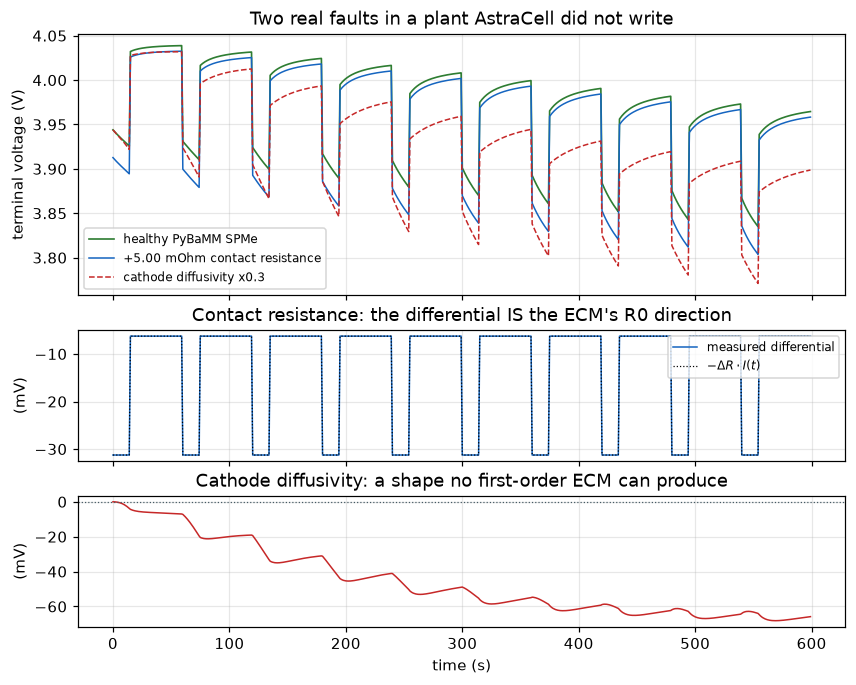

In [4]:
if PYBAMM_AVAILABLE:
    t = np.arange(N_TIME)
    fig, (top, mid, bot) = plt.subplots(3, 1, figsize=(9, 7), sharex=True, height_ratios=[2, 1, 1])
    top.plot(t, healthy_v, color="#2e7d32", lw=1.1, label="healthy PyBaMM SPMe")
    top.plot(t, faulty_v, color="#1565c0", lw=1.0, label=f"+{1e3*delta_r:.2f} mOhm contact resistance")
    top.plot(t, cathode_v, color="#c62828", lw=1.0, ls="--", label=f"cathode diffusivity x{CATHODE_SCALE}")
    top.set(ylabel="terminal voltage (V)", title="Two real faults in a plant AstraCell did not write")
    top.legend(fontsize=8); top.grid(alpha=0.3)

    mid.plot(t, 1e3 * (faulty_v - healthy_v), color="#1565c0", lw=1.0, label="measured differential")
    mid.plot(t, 1e3 * ohmic, color="black", lw=0.8, ls=":", label=r"$-\Delta R \cdot I(t)$")
    mid.set(ylabel="(mV)", title="Contact resistance: the differential IS the ECM's R0 direction")
    mid.legend(fontsize=8); mid.grid(alpha=0.3)

    bot.plot(t, 1e3 * (cathode_v - healthy_v), color="#c62828", lw=1.0)
    bot.axhline(0, color="#455a64", lw=0.8, ls=":")
    bot.set(xlabel="time (s)", ylabel="(mV)",
            title="Cathode diffusivity: a shape no first-order ECM can produce")
    bot.grid(alpha=0.3)
    plt.show()
else:
    print("PyBaMM not installed -- skipping the trace figure.")

---
## 3. Baseline subtraction and paired comparison are the same estimator

The brief offered these as alternatives. They are not — the projection is linear:

$$\mathrm{FIM}^{-1}S^\top\Sigma^{-1}(g_f - f) \;-\; \mathrm{FIM}^{-1}S^\top\Sigma^{-1}(g_h - f)
  \;\equiv\; \mathrm{FIM}^{-1}S^\top\Sigma^{-1}(g_f - g_h)$$

There was never a choice. What the identity *does* buy is honest noise: two measured traces carry two
independent draws, so the differential has covariance `2Σ` and the CRLB widens by `√2`. **Subtraction
is not free.**

In [5]:
if PYBAMM_AVAILABLE:
    healthy_ev, _ = evidence_for(HEALTHY, 0.0, CAPACITY_TARGET)
    huge, huge_v = evidence_for(contact_resistance(1.00 * OBSERVER_R0_OHM), 1.00, R0_TARGET)

    # v0.3's baseline-free gate, pointed at a cell whose series resistance has DOUBLED.
    v03_scn = external_scenario(name="v0.3", observer=observer, current_a=CURRENT, soc0=SOC0,
                                target_index=R0_TARGET)
    v03 = prepare_external(v03_scn, huge_v)                      # no baseline: exactly the v0.3 call
    v03_res = run_trials(v03_scn, 300, seed=SEED, estimator="linear", prepared=v03)
    print("v0.3's gate on a doubled series resistance (+25 mOhm):")
    print(f"  bias == estimate  {v03.target_bias:+.2%}     SNR_total  "
          f"{np.sqrt(np.mean(v03_res.snr_bias ** 2)):.4f} sigma")
    print(f"  verdicts          {v03_res.verdicts.count(VerdictKind.REFUSE_MODEL_BIAS)}/300 "
          f"REFUSE_MODEL_BIAS   <- it calls the fault 'bias'\n")

    print(f"healthy phantom on capacity       {healthy_ev.phantom:+.2%}   <- v0.3's headline")
    print(f"healthy phantom on R0             {strong.phantom:+.2%}")
    print(f"raw estimate (R0), 20% fault      {strong.raw_estimate:+.4%}")
    print(f"  minus the phantom               {strong.raw_estimate - strong.phantom:+.4%}")
    print(f"paired estimate (R0), 20% fault   {strong.paired_estimate:+.4%}   <- identical")
    print(f"residual of the identity          "
          f"{abs(strong.raw_estimate - strong.phantom - strong.paired_estimate):.2e}")
    print(f"\nsigma: raw {strong.raw.target_sigma:.3%}  ->  paired {strong.paired.target_sigma:.3%}"
          f"  (x{strong.paired.target_sigma / strong.raw.target_sigma:.3f})")
else:
    print("PyBaMM not installed -- skipping.")

v0.3's gate on a doubled series resistance (+25 mOhm):
  bias == estimate  +91.44%     SNR_total  1.0000 sigma
  verdicts          300/300 REFUSE_MODEL_BIAS   <- it calls the fault 'bias'

healthy phantom on capacity       -67.57%   <- v0.3's headline
healthy phantom on R0             -8.56%
raw estimate (R0), 20% fault      +11.4413%
  minus the phantom               +20.0000%
paired estimate (R0), 20% fault   +20.0000%   <- identical
residual of the identity          6.38e-16

sigma: raw 0.059%  ->  paired 0.084%  (x1.414)


### Diagnosis is not detection

A **true positive** requires DIAGNOSE *and* an interval that covers the injected truth *and* the right
sign. Scoring only harmful overclaim rewards silence; scoring only diagnosis rewards noise.

Watch what happens at a **100% fault** (a doubled series resistance). The raw path is finally loud
enough to clear its own phantom's gate — and diagnoses in every trial, reporting `+91.4%` against a
truth of `+100%`. An 8.6-point miss inside a 0.23%-wide interval, 145σ of misplaced confidence.

In [6]:
if PYBAMM_AVAILABLE:
    rows = [("raw (20% fault)", strong.raw), ("paired (20% fault)", strong.paired),
            ("raw (100% fault)", huge.raw), ("paired (100% fault)", huge.paired)]
    print(f"{'path':22s} {'diagnose':>9s} {'true pos':>9s} {'overclaim':>10s} {'cov 95%':>8s}")
    for label, ctx in rows:
        m = detection_metrics(run_trials(ctx.scenario, N_TRIALS, seed=SEED, prepared=ctx))
        print(f"{label:22s} {m.diagnosis_rate:9.2f} {m.true_positive_rate:9.2f} "
              f"{m.harmful_overclaim_rate:10.2f} {m.coverage:8.2f}")
    print(f"\nraw estimate at the 100% fault: {huge.raw_estimate:+.1%}   (truth +100%)")
    print("Right about the fault, wrong about the fault. Every diagnosis is a harmful overclaim.")
else:
    print("PyBaMM not installed -- skipping.")

path                    diagnose  true pos  overclaim  cov 95%
raw (20% fault)             0.00      0.00       0.00     0.00
paired (20% fault)          1.00      0.94       0.06     0.94
raw (100% fault)            1.00      0.00       1.00     0.00
paired (100% fault)         1.00      0.94       0.06     0.94

raw estimate at the 100% fault: +91.4%   (truth +100%)
Right about the fault, wrong about the fault. Every diagnosis is a harmful overclaim.


### Re-scoring v0.3's headline with the honest gate

The gate cannot use `parameter_bias` on data that might be faulted. What it *can* use is the part of
the residual **no parameter setting reproduces** — the out-of-span component `ρ̃ = (I−P)r̃`, which is
exactly independent of any fault present. Convert it to parameter units by Cauchy–Schwarz:

$$b^{\mathrm{lof}}_i = \lVert\tilde\rho\rVert \cdot \sigma_i$$

It is invariant to the noise scale, and exactly zero when the model reproduces the data. Apply it to
v0.3's healthy cell, where we *know* the entire estimate is bias, and it under-warns by **3.2×**.

In [7]:
if PYBAMM_AVAILABLE:
    b_lof = healthy_ev.raw_lack_of_fit
    truth_is_bias = abs(healthy_ev.raw_estimate)       # the cell is healthy: the estimate IS the bias
    snr_total = truth_is_bias / np.hypot(healthy_ev.raw.target_sigma, b_lof)

    print(f"capacity estimate      {healthy_ev.raw_estimate:+.2%}   <- and it is ALL bias")
    print(f"lack-of-fit bias       {b_lof:+.2%}   <- what the screen sees")
    print(f"SNR_total              {snr_total:.2f} sigma   <- WEAK_EVIDENCE, not REFUSE")
    print(f"fraction of bias seen  {b_lof / truth_is_bias:.0%}")
    print("\nv0.3's '100% REFUSE_MODEL_BIAS' becomes 'WEAK'. Harmful overclaim is still 0% -- WEAK")
    print("is not DIAGNOSE -- so the headline is corrected, not retracted. But the margin was")
    print("thinner than reported, and a phantom three times smaller would have slipped through.")
else:
    print("PyBaMM not installed -- skipping.")

capacity estimate      -67.57%   <- and it is ALL bias
lack-of-fit bias       +20.86%   <- what the screen sees
SNR_total              3.24 sigma   <- WEAK_EVIDENCE, not REFUSE
fraction of bias seen  31%

v0.3's '100% REFUSE_MODEL_BIAS' becomes 'WEAK'. Harmful overclaim is still 0% -- WEAK
is not DIAGNOSE -- so the headline is corrected, not retracted. But the margin was
thinner than reported, and a phantom three times smaller would have slipped through.


---
## 4. The magnitude sweep

Where diagnosis begins, where it must not, and the transition between. `b_lof` is zero to
floating-point dust throughout — the ECM reproduces a series resistance *exactly* — so the
credibility gate is inert and the verdicts are pure Cramér–Rao. The transition sits where `σ(ΔR) =
0.021 mΩ` puts it: 5σ is 0.105 mΩ.

Note the true-positive rate saturates at **0.94, not 1.00**. A 95% interval misses its truth 5% of
the time by construction, so 5% of confident, *correct* diagnoses are counted harmful overclaims.
Overclaim floors at `1 − coverage_level` for any detector that diagnoses at all. v0.3's 0% overclaim
came from 0% diagnosis; it is not a number to aspire to.

 dR [mOhm]       SNR  diagnose  true pos   weak  refuse


     0.013       0.6      0.00      0.00   0.07    0.93


     0.025       1.2      0.00      0.00   0.17    0.82


     0.050       2.4      0.00      0.00   0.64    0.36


     0.075       3.6      0.06      0.04   0.88    0.06


...

     0.250      12.0      1.00      0.94   0.00    0.00


     0.500      23.9      1.00      0.94   0.00    0.00


     1.250      59.8      1.00      0.94   0.00    0.00


     5.000     239.1      1.00      0.94   0.00    0.00


    25.000    1195.4      1.00      0.94   0.00    0.00


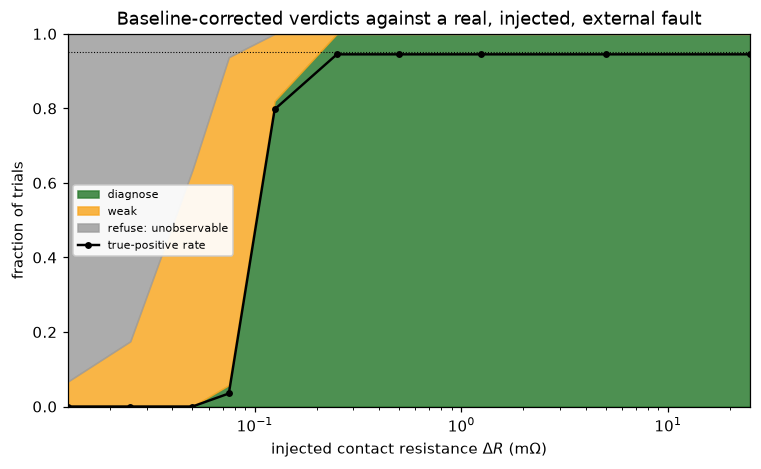

In [8]:
STYLE = {
    VerdictKind.DIAGNOSE: ("#2e7d32", "diagnose"),
    VerdictKind.WEAK_EVIDENCE: ("#f9a825", "weak"),
    VerdictKind.REFUSE_UNOBSERVABLE: ("#9e9e9e", "refuse: unobservable"),
    VerdictKind.REFUSE_CONFOUNDED: ("#6a1b9a", "refuse: confounded"),
    VerdictKind.REFUSE_MODEL_BIAS: ("#c62828", "refuse: model bias"),
}
SWEEP = (0.0005, 0.001, 0.002, 0.003, 0.005, 0.01, 0.02, 0.05, 0.2, 1.0)

if PYBAMM_AVAILABLE:
    fractions = {k: np.zeros(len(SWEEP)) for k in VerdictKind}
    tpr = []
    print(f"{'dR [mOhm]':>10s} {'SNR':>9s} {'diagnose':>9s} {'true pos':>9s} {'weak':>6s} {'refuse':>7s}")
    for i, frac in enumerate(SWEEP):
        ev, _ = evidence_for(contact_resistance(frac * OBSERVER_R0_OHM), frac, R0_TARGET)
        res = run_trials(ev.paired.scenario, N_TRIALS, seed=SEED, prepared=ev.paired)
        m = detection_metrics(res)
        for k, share in verdict_distribution(res).items():
            fractions[k][i] = share
        tpr.append(m.true_positive_rate)
        snr = abs(ev.paired_estimate) / ev.paired.target_sigma
        print(f"{1e3*frac*OBSERVER_R0_OHM:10.3f} {snr:9.1f} {m.diagnosis_rate:9.2f} "
              f"{m.true_positive_rate:9.2f} {m.weak_rate:6.2f} {m.refusal_rate:7.2f}")

    x = 1e3 * np.array(SWEEP) * OBSERVER_R0_OHM
    fig, ax = plt.subplots(figsize=(8, 4.4))
    bottom = np.zeros(len(SWEEP))
    for k in VerdictKind:
        if fractions[k].max() == 0.0:
            continue
        colour, name = STYLE[k]
        ax.fill_between(x, bottom, bottom + fractions[k], color=colour, alpha=0.85, label=name)
        bottom = bottom + fractions[k]
    ax.plot(x, tpr, color="black", lw=1.6, marker="o", ms=3.5, label="true-positive rate")
    ax.axhline(0.95, color="black", lw=0.7, ls=":")
    ax.set(xscale="log", xlabel=r"injected contact resistance $\Delta R$ (m$\Omega$)",
           ylabel="fraction of trials", ylim=(0, 1),
           title="Baseline-corrected verdicts against a real, injected, external fault")
    ax.margins(x=0); ax.legend(fontsize=7, loc="center left", framealpha=0.92)
    plt.show()
else:
    print("PyBaMM not installed -- skipping the sweep.")

---
## 5. The confounder, refused — by one percent

Cathode diffusivity `×0.3` is a **real physical degradation** whose true `(R₀, capacity)` deviation is
`(0, 0)`. That is not asserted from the parameter we set — it is measured. The faulted C/20 curve
shifts by 9.6 mV RMS (an earlier draft wrongly called it "unchanged"), but the shift is **linear in
current** — 199 mV per C over a 10× rate range — hence an overpotential, hence extrapolating to zero.
The equilibrium OCV–SOC relation, and with it the coulombic capacity, is untouched.

Variance alone would diagnose a 13% resistance fault at 158σ and a 119% capacity loss at 579σ. The
lack-of-fit says: *no setting of my parameters produces this differential.* Refuse.

**Watch the margin on the capacity row.**

In [9]:
if PYBAMM_AVAILABLE:
    capacity_ev, _ = evidence_for(slow_cathode(CATHODE_SCALE), 0.0, CAPACITY_TARGET)
    print(f"{'hypothesis':12s} {'paired est':>12s} {'SNR var':>9s} {'b_lof':>9s} {'SNR tot':>9s}  verdict")
    for label, ev in (("R0", confounder), ("capacity", capacity_ev)):
        sv = abs(ev.paired_estimate) / ev.paired.target_sigma
        st = abs(ev.paired_estimate) / np.hypot(ev.paired.target_sigma, ev.lack_of_fit)
        res = run_trials(ev.paired.scenario, N_TRIALS, seed=SEED, prepared=ev.paired)
        top = max(verdict_distribution(res).items(), key=lambda kv: kv[1])[0]
        print(f"{label:12s} {ev.paired_estimate:12.2%} {sv:9.1f} {ev.lack_of_fit:9.2%} {st:9.2f}  "
              f"{top.value.upper()}")
    print("\nThe capacity hypothesis clears the 2-sigma line at 1.98 sigma -- refused by 1%. The")
    print("screen is doing real work and has nothing to spare. Shorten the window to 300 s and the")
    print("very same hypothesis reaches 3.35 sigma and is merely WEAK.")
else:
    print("PyBaMM not installed -- skipping the confounder.")

hypothesis     paired est   SNR var     b_lof   SNR tot  verdict
R0                 13.19%     157.7    24.48%      0.54  REFUSE_MODEL_BIAS
capacity         -118.77%     579.2    60.01%      1.98  REFUSE_MODEL_BIAS

The capacity hypothesis clears the 2-sigma line at 1.98 sigma -- refused by 1%. The
screen is doing real work and has nothing to spare. Shorten the window to 300 s and the
very same hypothesis reaches 3.35 sigma and is merely WEAK.


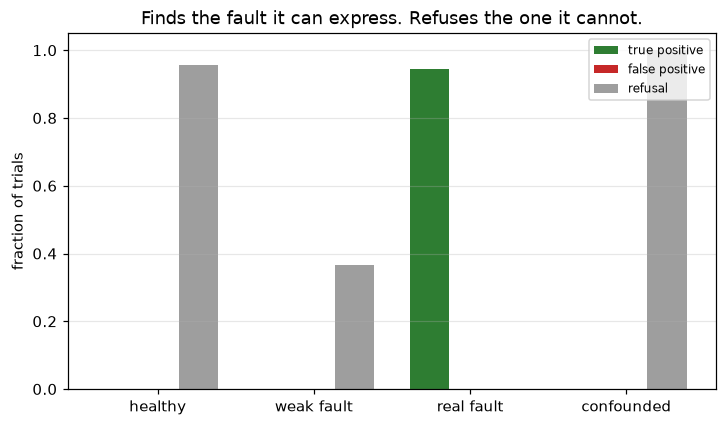

In [10]:
if PYBAMM_AVAILABLE:
    weak_ev, _ = evidence_for(contact_resistance(0.002 * OBSERVER_R0_OHM), 0.002, R0_TARGET)
    healthy_r0, _ = evidence_for(HEALTHY, 0.0, R0_TARGET)
    cases = [("healthy", healthy_r0), ("weak fault", weak_ev),
             ("real fault", strong), ("confounded", confounder)]

    labels, tprs, fprs, refusals = [], [], [], []
    for label, ev in cases:
        m = detection_metrics(run_trials(ev.paired.scenario, N_TRIALS, seed=SEED, prepared=ev.paired))
        labels.append(label); tprs.append(m.true_positive_rate)
        fprs.append(m.false_positive_rate); refusals.append(m.refusal_rate)

    fig, ax = plt.subplots(figsize=(7.6, 4.2))
    idx = np.arange(len(labels))
    ax.bar(idx - 0.26, tprs, 0.25, color="#2e7d32", label="true positive")
    ax.bar(idx, fprs, 0.25, color="#c62828", label="false positive")
    ax.bar(idx + 0.26, refusals, 0.25, color="#9e9e9e", label="refusal")
    ax.set(ylabel="fraction of trials", ylim=(0, 1.05), xticks=idx, xticklabels=labels,
           title="Finds the fault it can express. Refuses the one it cannot.")
    ax.legend(fontsize=8); ax.grid(alpha=0.3, axis="y")
    plt.show()
else:
    print("PyBaMM not installed -- skipping the rates figure.")

---
## What this notebook validated, and what it did not

**Validated (synthetically, against a plant we did not design, with a fault we did):**

- v0.3's external bias gate refused **unconditionally**: its "structural bias" was algebraically equal
  to the estimate it gated, so `SNR_total ≡ 1` for any data. A negative control could never have
  revealed this. A positive control did, immediately.
- Baseline subtraction and paired comparison are the **same estimator**, exactly (identity residual
  `6 × 10⁻¹⁶`), at the price of a `√2` wider σ.
- With a healthy baseline the same gate **discriminates**: it recovers a real injected fault at its
  correct magnitude with nominal coverage, weakens a marginal one, and still refuses a real physical
  change it cannot name.
- **Diagnosis is not detection.** The raw path diagnoses a doubled series resistance in every trial
  while reporting it 145σ from the truth.

**Not validated, and not claimable:**

- Anything about a **real battery**. PyBaMM is a model; the fault is one we injected into it.
- **The baseline.** `g_h` here is the *identical simulation*. A real beginning-of-life fingerprint is
  a different day, temperature, SOC window, and cell. Every rate above is an **upper bound**.
- **The screen bounds nothing.** `b_lof` sees only the out-of-span residual. On the one case with known
  truth it captures **31%** of the bias. A structural error lying entirely *in* the span is invisible to
  it — and to every other method that looks only at this experiment.
- **The primary fault is in the model's span by construction.** A contact resistance *is* what an
  ECM's `R₀` is. Recovering it demonstrates the plumbing, not the physics. The confounder is where the
  physics is, and there the margin is **1%**.
- **Capacity fade is still not injected.** It cannot be, cleanly, without breaking the shared-OCV
  control. [`LIMITATIONS.md`](../LIMITATIONS.md) §15.

v0.4 does not make AstraCell better at diagnosing. It makes the refusal **mean something** — and it
found a place where v0.3's refusal did not.

Full accounting: [`docs/POSITIVE_CONTROL.md`](../docs/POSITIVE_CONTROL.md) and
[`LIMITATIONS.md`](../LIMITATIONS.md) §15.